# Aula 02 — Relacionamento Básico entre Pixels

**Visão Computacional — Sistemas de Informação**

A sequência acompanha a organização da aula: **vizinhança → conectividade/adjacência → distâncias → operações aritméticas → operações lógicas**.

## 0. Preparação

Bibliotecas utilizadas:

- **NumPy** — representação e manipulação das matrizes de pixels;
- **Matplotlib** — visualização;
- **OpenCV** — operações de processamento de imagens.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["image.cmap"] = "gray"

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.0.2
OpenCV: 5.0.0


# 1. Vizinhança de um pixel

Para um pixel `p = (x,y)`:

- **N4(p)**: vizinhos horizontal e vertical;
- **ND(p)**: vizinhos diagonais;
- **N8(p)**: `N4(p) ∪ ND(p)`.

Primeiro vamos usar uma matriz pequena.

In [ ]:
imagem = np.arange(25).reshape(5, 5)
linha, coluna = 2, 2

print("Imagem:")
print(imagem)
print("\nPixel p =", imagem[linha, coluna])
print("Coordenada (linha, coluna) =", (linha, coluna))

Imagem:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

Pixel p = 12
Coordenada (linha, coluna) = (2, 2)


In [ ]:
def vizinhanca_4(linha, coluna, altura, largura):
    """Retorna as coordenadas dos vizinhos N4."""
    vizinhos = []
    for dl, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        l, c = linha + dl, coluna + dc
        if 0 <= l < altura and 0 <= c < largura:
            vizinhos.append((l, c))
    return vizinhos


def vizinhanca_diagonal(linha, coluna, altura, largura):
    """Retorna as coordenadas dos vizinhos diagonais ND."""
    vizinhos = []
    for dl, dc in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
        l, c = linha + dl, coluna + dc
        if 0 <= l < altura and 0 <= c < largura:
            vizinhos.append((l, c))
    return vizinhos


def vizinhanca_8(linha, coluna, altura, largura):
    return vizinhanca_4(linha, coluna, altura, largura) + vizinhanca_diagonal(
        linha, coluna, altura, largura
    )


n4 = vizinhanca_4(linha, coluna, *imagem.shape)
nd = vizinhanca_diagonal(linha, coluna, *imagem.shape)
n8 = vizinhanca_8(linha, coluna, *imagem.shape)

print("N4:", n4)
print("ND:", nd)
print("N8:", n8)

N4: [(1, 2), (3, 2), (2, 1), (2, 3)]
ND: [(1, 1), (1, 3), (3, 1), (3, 3)]
N8: [(1, 2), (3, 2), (2, 1), (2, 3), (1, 1), (1, 3), (3, 1), (3, 3)]


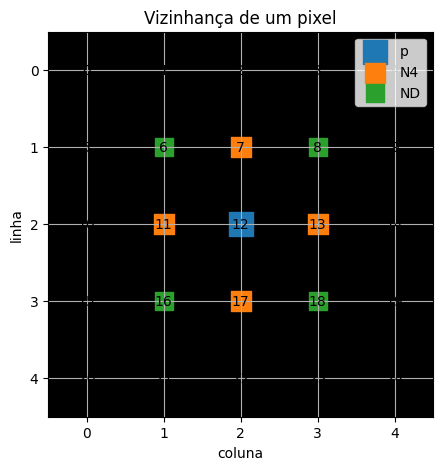

In [ ]:
fig, ax = plt.subplots()

ax.imshow(np.zeros_like(imagem), vmin=0, vmax=1)

ax.scatter([coluna], [linha], s=300, marker="s", label="p")
ax.scatter([c for l, c in n4], [l for l, c in n4], s=220, marker="s", label="N4")
ax.scatter([c for l, c in nd], [l for l, c in nd], s=180, marker="s", label="ND")

for i in range(imagem.shape[0]):
    for j in range(imagem.shape[1]):
        ax.text(j, i, str(imagem[i, j]), ha="center", va="center")

ax.set_xticks(range(imagem.shape[1]))
ax.set_yticks(range(imagem.shape[0]))
ax.set_xlabel("coluna")
ax.set_ylabel("linha")
ax.set_title("Vizinhança de um pixel")
ax.grid(True)
ax.legend()
plt.show()

### Interpretação

O conceito de **vizinhança** trata da proximidade espacial. Neste momento, não estamos considerando se os pixels possuem valores semelhantes.

Na **conectividade**, acrescentamos o critério de similaridade.

# 2. Conectividade / Adjacência

Dois pixels são considerados conectados quando:

1. são vizinhos segundo N4, ND ou N8; e
2. seus valores pertencem a um conjunto pré-definido `V`.

Para uma imagem binária, normalmente usamos `V = {1}`.

Vamos comparar conectividade 4 e 8.

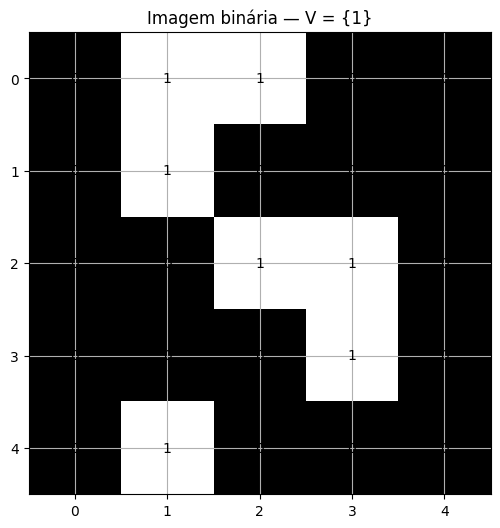

In [ ]:
binaria = np.array([
    [0, 1, 1, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0]
], dtype=np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(binaria, vmin=0, vmax=1)
for i in range(binaria.shape[0]):
    for j in range(binaria.shape[1]):
        plt.text(j, i, str(binaria[i, j]), ha="center", va="center")
plt.xticks(range(binaria.shape[1]))
plt.yticks(range(binaria.shape[0]))
plt.grid(True)
plt.title("Imagem binária — V = {1}")
plt.show()

In [ ]:
num4, labels4, stats4, centroids4 = cv2.connectedComponentsWithStats(
    binaria, connectivity=4
)

num8, labels8, stats8, centroids8 = cv2.connectedComponentsWithStats(
    binaria, connectivity=8
)

print("Componentes de objeto (sem contar o fundo):")
print("Conectividade 4:", num4 - 1)
print("Conectividade 8:", num8 - 1)

Componentes de objeto (sem contar o fundo):
Conectividade 4: 3
Conectividade 8: 2


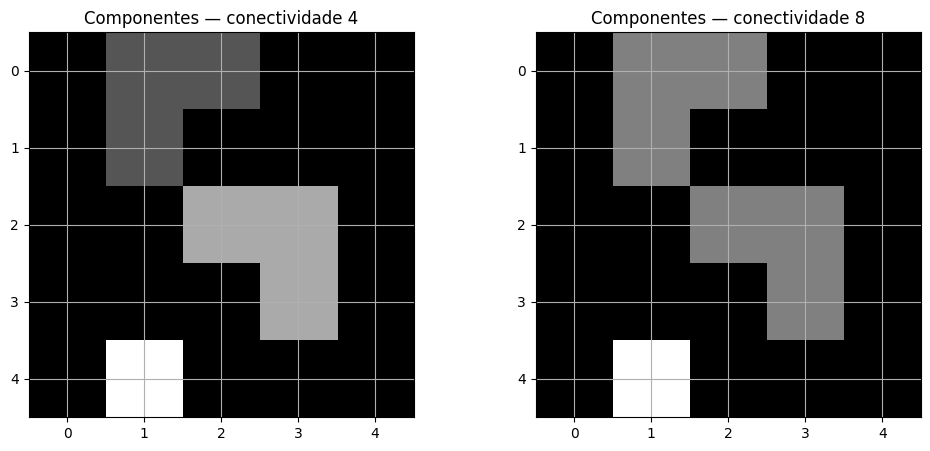

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(labels4)
axes[0].set_title("Componentes — conectividade 4")

axes[1].imshow(labels8)
axes[1].set_title("Componentes — conectividade 8")

for ax in axes:
    ax.set_xticks(range(binaria.shape[1]))
    ax.set_yticks(range(binaria.shape[0]))
    ax.grid(True)

plt.show()

# 3. Medidas de distância

Vamos usar os pontos:

- `p = (1,1)`
- `q = (4,3)`

E calcular:

- Euclidiana;
- City Block (Quarteirão);
- Chessboard (Xadrez).

In [ ]:
p = (1, 1)
q = (4, 3)

x1, y1 = p
x2, y2 = q

euclidiana = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
city_block = abs(x2 - x1) + abs(y2 - y1)
chessboard = max(abs(x2 - x1), abs(y2 - y1))

print("p =", p)
print("q =", q)
print()
print("Euclidiana:", euclidiana)
print("City Block:", city_block)
print("Chessboard:", chessboard)

p = (1, 1)
q = (4, 3)

Euclidiana: 3.605551275463989
City Block: 5
Chessboard: 3


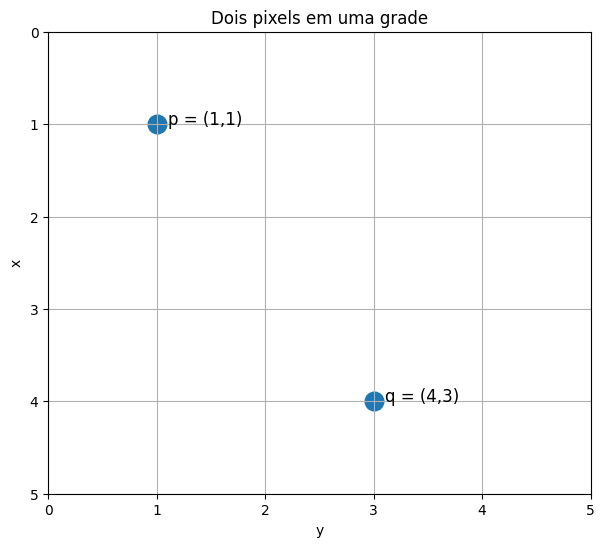

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter([y1, y2], [x1, x2], s=180)
plt.text(y1 + 0.1, x1, "p = (1,1)", fontsize=12)
plt.text(y2 + 0.1, x2, "q = (4,3)", fontsize=12)

plt.xticks(range(0, 6))
plt.yticks(range(0, 6))
plt.xlabel("y")
plt.ylabel("x")
plt.title("Dois pixels em uma grade")
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

### Resultado esperado

Para `p = (1,1)` e `q = (4,3)`:

- Euclidiana: `√13 ≈ 3,61`
- City Block: `5`
- Chessboard: `3`

# 4. Operações aritméticas entre imagens

As operações são:

- adição;
- subtração;
- multiplicação;
- divisão.

São **operações pontuais**: o pixel `(x,y)` da imagem resultante depende dos pixels nas mesmas coordenadas das imagens de entrada.

Vamos começar com matrizes pequenas.

In [ ]:
A = np.array([
    [50,  80, 100, 120],
    [20,  40,  60,  80],
    [10,  30,  50,  70],
    [ 0, 20,  40,  60]
], dtype=np.uint8)

B = np.array([
    [10, 20, 30, 40],
    [10, 20, 30, 40],
    [10, 20, 30, 40],
    [10, 20, 30, 40]
], dtype=np.uint8)

print("A =")
print(A)
print("\nB =")
print(B)

A =
[[ 50  80 100 120]
 [ 20  40  60  80]
 [ 10  30  50  70]
 [  0  20  40  60]]

B =
[[10 20 30 40]
 [10 20 30 40]
 [10 20 30 40]
 [10 20 30 40]]


In [ ]:
A_float = A.astype(np.float32)
B_float = B.astype(np.float32)

soma = A_float + B_float
subtracao = A_float - B_float
multiplicacao = A_float * B_float
divisao = A_float / np.maximum(B_float, 1)

soma_u8 = np.clip(soma, 0, 255).astype(np.uint8)
subtracao_u8 = np.clip(subtracao, 0, 255).astype(np.uint8)
multiplicacao_u8 = np.clip(multiplicacao, 0, 255).astype(np.uint8)
divisao_u8 = np.clip(divisao, 0, 255).astype(np.uint8)

print("A + B =\n", soma_u8)
print("\nA - B =\n", subtracao_u8)
print("\nA * B =\n", multiplicacao_u8)
print("\nA / B =\n", divisao_u8)

A + B =
 [[ 60 100 130 160]
 [ 30  60  90 120]
 [ 20  50  80 110]
 [ 10  40  70 100]]

A - B =
 [[40 60 70 80]
 [10 20 30 40]
 [ 0 10 20 30]
 [ 0  0 10 20]]

A * B =
 [[255 255 255 255]
 [200 255 255 255]
 [100 255 255 255]
 [  0 255 255 255]]

A / B =
 [[5 4 3 3]
 [2 2 2 2]
 [1 1 1 1]
 [0 1 1 1]]


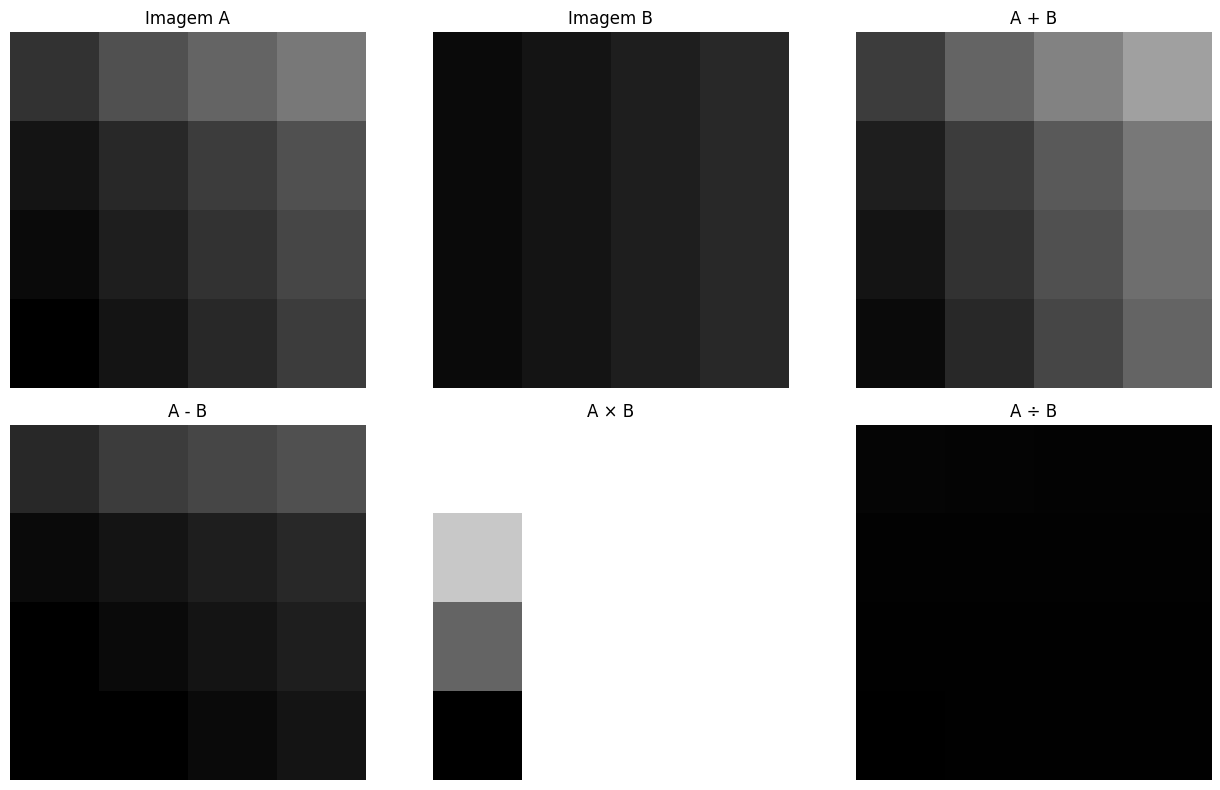

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

imagens = [
    (A, "Imagem A"),
    (B, "Imagem B"),
    (soma_u8, "A + B"),
    (subtracao_u8, "A - B"),
    (multiplicacao_u8, "A × B"),
    (divisao_u8, "A ÷ B")
]

for ax, (img, titulo) in zip(axes.ravel(), imagens):
    ax.imshow(img, vmin=0, vmax=255)
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4.1. Adição de um escalar: brilho

Adicionar um escalar positivo a todos os pixels pode aumentar o brilho uniformemente.

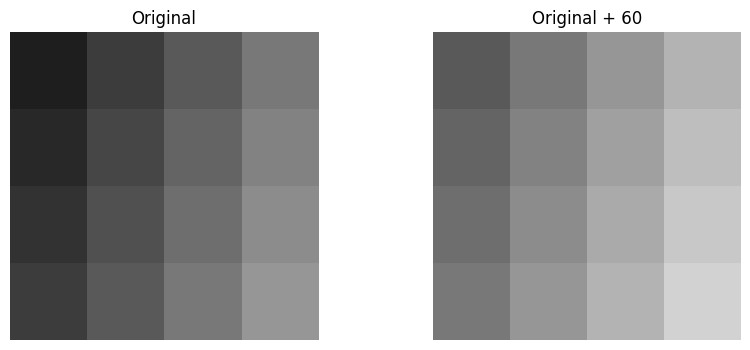

In [ ]:
imagem_base = np.array([
    [30,  60,  90, 120],
    [40,  70, 100, 130],
    [50,  80, 110, 140],
    [60,  90, 120, 150]
], dtype=np.uint8)

imagem_mais_brilho = np.clip(
    imagem_base.astype(np.int16) + 60, 0, 255
).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(imagem_base, vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(imagem_mais_brilho, vmin=0, vmax=255)
axes[1].set_title("Original + 60")

for ax in axes:
    ax.axis("off")

plt.show()

## 4.2. Subtração: evidenciar diferenças

Vamos criar duas imagens da mesma cena e alterar apenas uma região. A diferença deverá destacar a mudança.

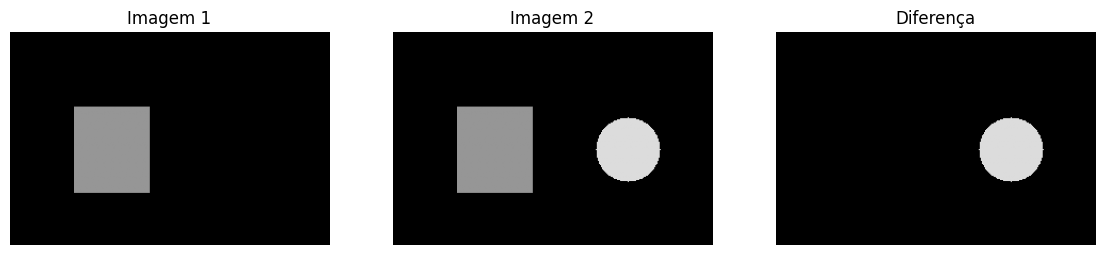

In [ ]:
cena1 = np.zeros((200, 300), dtype=np.uint8)
cena2 = cena1.copy()

cv2.rectangle(cena1, (60, 70), (130, 150), 150, -1)
cv2.rectangle(cena2, (60, 70), (130, 150), 150, -1)

# Alteração presente somente na segunda imagem
cv2.circle(cena2, (220, 110), 30, 220, -1)

diferenca = cv2.absdiff(cena1, cena2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cena1, vmin=0, vmax=255)
axes[0].set_title("Imagem 1")
axes[1].imshow(cena2, vmin=0, vmax=255)
axes[1].set_title("Imagem 2")
axes[2].imshow(diferenca, vmin=0, vmax=255)
axes[2].set_title("Diferença")

for ax in axes:
    ax.axis("off")

plt.show()

### Interpretação

Na imagem de diferença:

- regiões iguais tendem a ficar escuras;
- regiões que mudaram aparecem com intensidade maior.

Isso ilustra a aplicação da subtração para **detectar mudanças**, como em vigilância ou comparação de imagens. Em imagens reais, iluminação, posição da câmera e ruído podem gerar alterações que não correspondem ao objeto de interesse.

# 5. Multiplicação e divisão por escalar

Agora vamos demonstrar o efeito sobre o brilho de uma imagem:

- multiplicar por `2` aumenta os valores;
- dividir por `2` reduz os valores.

Como trabalhamos com imagens de 8 bits, vamos limitar os resultados ao intervalo `[0,255]`.

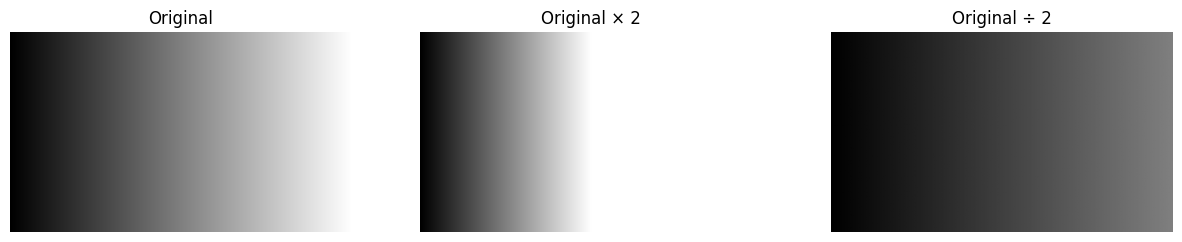

In [ ]:
gradiente = np.tile(
    np.linspace(0, 255, 256, dtype=np.uint8),
    (150, 1)
)

mais_clara = np.clip(gradiente.astype(np.float32) * 2, 0, 255).astype(np.uint8)
mais_escura = np.clip(gradiente.astype(np.float32) / 2, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(gradiente, vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(mais_clara, vmin=0, vmax=255)
axes[1].set_title("Original × 2")

axes[2].imshow(mais_escura, vmin=0, vmax=255)
axes[2].set_title("Original ÷ 2")

for ax in axes:
    ax.axis("off")

plt.show()

# 6. Operações lógicas em imagens binárias

A aula apresenta:

- **AND**
- **OR**
- **NOT**
- **XOR**

Em imagens binárias:

- `0` representa preto;
- `255` representa branco.

Vamos criar duas máscaras com formas geométricas e observar o resultado de cada operação.

In [ ]:
mask_a = np.zeros((250, 250), dtype=np.uint8)
mask_b = np.zeros((250, 250), dtype=np.uint8)

cv2.rectangle(mask_a, (50, 70), (170, 190), 255, -1)
cv2.circle(mask_b, (150, 130), 65, 255, -1)

print("Valores em A:", np.unique(mask_a))
print("Valores em B:", np.unique(mask_b))

Valores em A: [  0 255]
Valores em B: [  0 255]


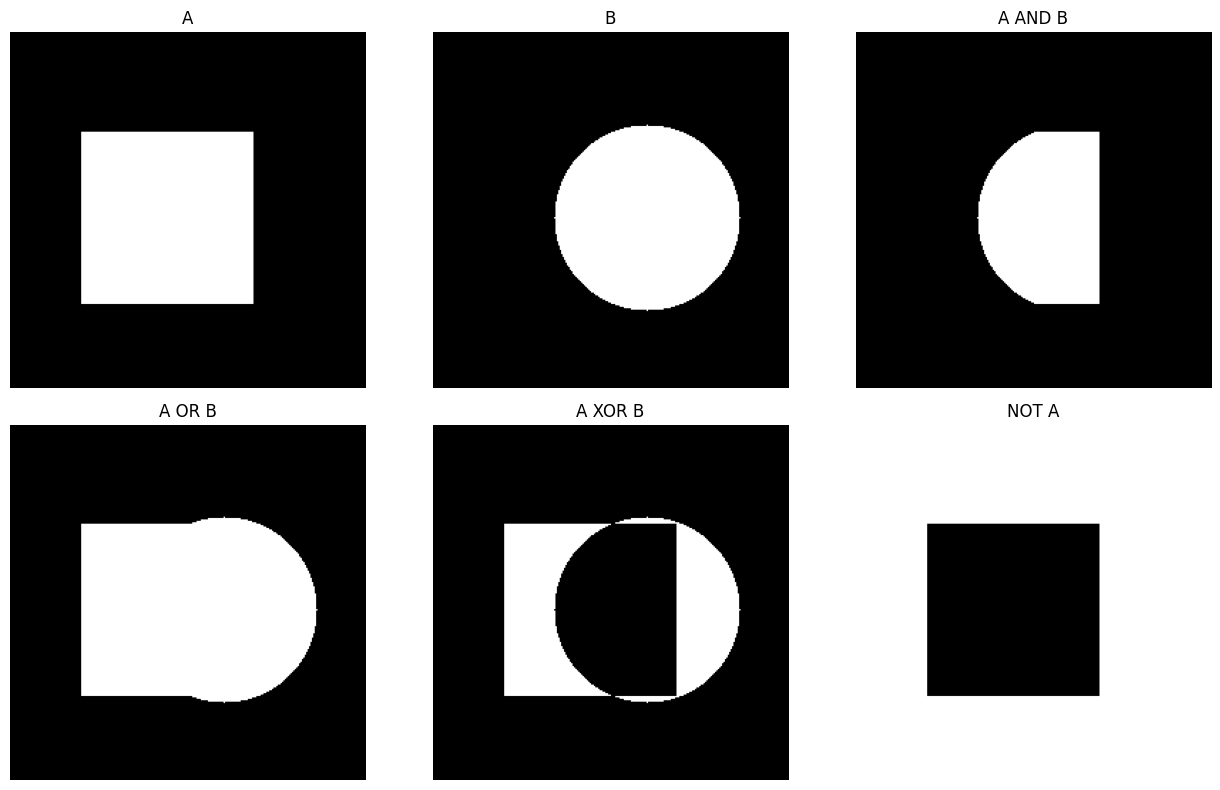

In [ ]:
and_img = cv2.bitwise_and(mask_a, mask_b)
or_img = cv2.bitwise_or(mask_a, mask_b)
xor_img = cv2.bitwise_xor(mask_a, mask_b)
not_img = cv2.bitwise_not(mask_a)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

imagens_logicas = [
    (mask_a, "A"),
    (mask_b, "B"),
    (and_img, "A AND B"),
    (or_img, "A OR B"),
    (xor_img, "A XOR B"),
    (not_img, "NOT A")
]

for ax, (img, titulo) in zip(axes.ravel(), imagens_logicas):
    ax.imshow(img, vmin=0, vmax=255)
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6.1. Relacionando com a tabela-verdade

Para um pixel, as operações são:

| A | B | AND | OR | XOR |
|---|---|---|---|---|
| 0 | 0 | 0 | 0 | 0 |
| 0 | 1 | 0 | 1 | 1 |
| 1 | 0 | 0 | 1 | 1 |
| 1 | 1 | 1 | 1 | 0 |

Uma imagem inteira pode ser entendida como a aplicação dessa lógica **pixel a pixel**.

In [ ]:
print("A B | AND OR XOR")
print("----------------")

for a in [0, 1]:
    for b in [0, 1]:
        print(a, b, "| ", a & b, " ", a | b, " ", a ^ b)

A B | AND OR XOR
----------------
0 0 |  0   0   0
0 1 |  0   1   1
1 0 |  0   1   1
1 1 |  1   1   0


# 7. Aplicação: máscaras

Uso de operações lógicas em tarefas de manipulação de imagens e máscaras.

Vamos selecionar uma região de uma imagem usando uma máscara. O princípio é:

**imagem AND máscara → preserva somente a região selecionada.**

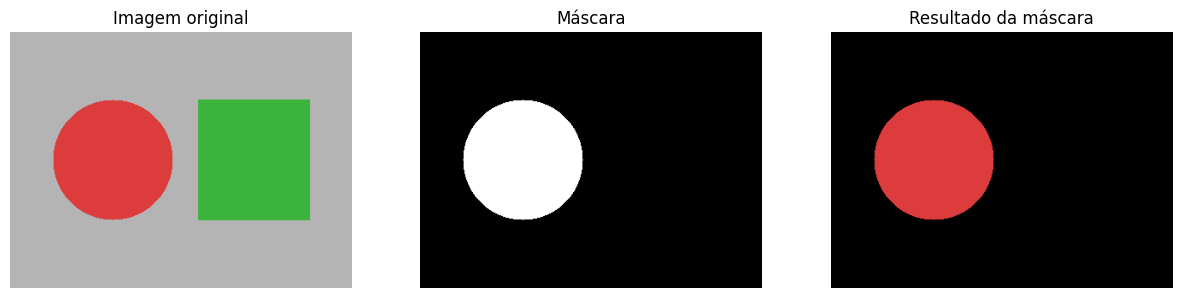

In [ ]:
imagem_colorida = np.zeros((300, 400, 3), dtype=np.uint8)
imagem_colorida[:] = (180, 180, 180)

cv2.circle(imagem_colorida, (120, 150), 70, (60, 60, 220), -1)
cv2.rectangle(imagem_colorida, (220, 80), (350, 220), (60, 180, 60), -1)

mascara = np.zeros((300, 400), dtype=np.uint8)
cv2.circle(mascara, (120, 150), 70, 255, -1)

resultado_mascara = cv2.bitwise_and(
    imagem_colorida,
    imagem_colorida,
    mask=mascara
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(imagem_colorida, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagem original")

axes[1].imshow(mascara, vmin=0, vmax=255)
axes[1].set_title("Máscara")

axes[2].imshow(cv2.cvtColor(resultado_mascara, cv2.COLOR_BGR2RGB))
axes[2].set_title("Resultado da máscara")

for ax in axes:
    ax.axis("off")

plt.show()